# Prophet Experiments for RDU Hourly Temperature

This notebook only uses the training split to fit Prophet candidates and the validation split to choose the best parameters. It does not write outputs to any folder and does not use the test set.

## Selected Validation Result

Best validation Prophet: `best_guess_regularized`

Locked parameters selected from validation:

| Parameter | Value |
|---|---:|
| `changepoint_prior_scale` | 0.01 |
| `seasonality_prior_scale` | 1.0 |
| `daily_fourier_order` | 16 |
| `yearly_fourier_order` | 20 |
| `weekly_seasonality` | True |
| `seasonality_mode` | additive |

Validation metrics for the selected Prophet model:

| Metric | Value |
|---|---:|
| MAE | 4.129 °F |
| RMSE | 5.340 °F |
| MASE | 0.705 |
| R² | 0.508 |
| Bias | -1.670 °F |
| Hours evaluated | 336 |

The final locked configuration selected here should be used separately in `src/prophet_model.py` for train + validation training and test evaluation.


In [35]:
import contextlib
import io
import logging
import os
import tempfile
import warnings
from pathlib import Path

CACHE_DIR = Path(tempfile.gettempdir()) / "prophet-notebook-cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_DIR / "xdg"))

import matplotlib

if not hasattr(__builtins__, "__IPYTHON__"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

with contextlib.redirect_stderr(io.StringIO()):
    from prophet import Prophet

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("cmdstanpy").disabled = True

DATA_DIR = Path("../data/processed")
REGRESSORS = ["hour_sin", "hour_cos", "year_sin", "year_cos"]
pd.options.display.float_format = "{:.3f}".format

## Load Train And Validation Splits

Prophet expects timezone-naive timestamps. The processed data is stored in UTC, so the code preserves the UTC clock time and removes the timezone marker.

In [36]:
def load_split(name):
    df = pd.read_csv(DATA_DIR / f"{name}.csv")
    df["ds"] = pd.to_datetime(df["ds"], utc=True).dt.tz_localize(None)
    return df.sort_values("ds").reset_index(drop=True)

train = load_split("train")
val = load_split("val")
train_clean = train.dropna(subset=["y"]).copy()

print("Train hours:", len(train))
print("Validation hours:", len(val))
print("Missing training targets:", train["y"].isna().sum())
print("Missing validation targets:", val["y"].isna().sum())
print("Train range:", train["ds"].min(), "to", train["ds"].max())
print("Validation range:", val["ds"].min(), "to", val["ds"].max())

Train hours: 101976
Validation hours: 336
Missing training targets: 157
Missing validation targets: 0
Train range: 2015-01-01 00:00:00 to 2026-08-19 23:00:00
Validation range: 2026-08-20 00:00:00 to 2026-09-02 23:00:00


## Metrics

MASE uses a 24-hour seasonal naive scale, which compares errors against the simple rule “same hour yesterday.”

In [37]:
def make_mase_scale(train_df, lag=24):
    # Keep the complete hourly timeline, including missing temperatures
    data = train_df.sort_values("ds").copy()

    # Check that each row represents one consecutive hour
    assert data["ds"].diff().dropna().eq(
        pd.Timedelta(hours=1)
    ).all(), "MASE requires a complete hourly timeline."

    y = data.set_index("ds")["y"]

    # Compare each temperature with the temperature 24 hours earlier
    # Missing pairs are automatically excluded from the mean
    scale = (y - y.shift(lag)).abs().mean()

    if not np.isfinite(scale) or scale <= 0:
        raise ValueError("MASE scale is zero or invalid.")

    return float(scale)

MASE_SCALE = make_mase_scale(train, lag=24)
print(f"MASE seasonal-naive scale, lag=24: {MASE_SCALE:.3f} °F")


def score_predictions(y_true, y_pred, model_name):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).astype(float)
    mask = y_true.notna() & y_pred.notna() & np.isfinite(y_pred)
    actual = y_true[mask]
    predicted = y_pred[mask]
    mae = mean_absolute_error(actual, predicted)
    return {
        "model": model_name,
        "mae": mae,
        "rmse": np.sqrt(mean_squared_error(actual, predicted)),
        "mase": mae / MASE_SCALE,
        "r2": r2_score(actual, predicted),
        "bias": float((predicted - actual).mean()),
        "hours": int(mask.sum()),
    }

MASE seasonal-naive scale, lag=24: 5.860 °F


## Reference Baselines

These simple validation baselines help interpret the Prophet score. They are included only for context, not as final model candidates.

In [38]:
def make_benchmarks(train_df, future_df):
    rows = []

    last_24 = train_df.dropna(subset=["y"]).tail(24)["y"].to_numpy()
    repeat_last_day = np.resize(last_24, len(future_df))
    rows.append(score_predictions(future_df["y"], repeat_last_day, "naive_repeat_last_train_day"))

    climatology = (
        train_df.dropna(subset=["y"])
        .assign(month=lambda x: x["ds"].dt.month, hour=lambda x: x["ds"].dt.hour)
        .groupby(["month", "hour"])["y"]
        .mean()
    )
    keys = list(zip(future_df["ds"].dt.month, future_df["ds"].dt.hour))
    month_hour_pred = [climatology.get(key, train_df["y"].mean()) for key in keys]
    rows.append(score_predictions(future_df["y"], month_hour_pred, "month_hour_climatology"))

    return pd.DataFrame(rows)

benchmark_metrics = make_benchmarks(train, val)
benchmark_metrics

,model,mae,rmse,mase,r2,bias,hours
0,naive_repeat_last_train_day,5.414,6.491,0.924,0.273,4.086,336
1,month_hour_climatology,4.674,6.279,0.798,0.320,-1.071,336


## Prophet Helper Functions

In [39]:
def build_prophet_model(config):
    model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=config.get("weekly_seasonality", False),
        yearly_seasonality=False,
        changepoint_prior_scale=config["changepoint_prior_scale"],
        seasonality_prior_scale=config["seasonality_prior_scale"],
        seasonality_mode=config.get("seasonality_mode", "additive"),
        interval_width=0.8,
    )
    model.add_seasonality(name="daily", period=1, fourier_order=config["daily_fourier_order"])
    model.add_seasonality(name="yearly", period=365.25, fourier_order=config["yearly_fourier_order"])

    if config.get("monthly_seasonality"):
        model.add_seasonality(
            name="monthly",
            period=30.5,
            fourier_order=config["monthly_fourier_order"],
        )

    if config.get("regressors"):
        for regressor in REGRESSORS:
            model.add_regressor(regressor, standardize=False)

    return model


def fit_predict_prophet(train_df, future_df, config):
    train_cols = ["ds", "y"] + (REGRESSORS if config.get("regressors") else [])
    future_cols = ["ds"] + (REGRESSORS if config.get("regressors") else [])

    model = build_prophet_model(config)
    model.fit(train_df[train_cols].dropna(subset=["y"]))
    forecast = model.predict(future_df[future_cols])
    return forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]], model


def compare_forecast(actual_df, forecast_df):
    comparison = actual_df[["ds", "y"]].merge(
        forecast_df[["ds", "yhat", "yhat_lower", "yhat_upper"]],
        on="ds",
        how="left",
        validate="one_to_one",
    )
    assert np.isfinite(comparison["yhat"]).all()
    return comparison

## Parameter Search On Validation Set

This compact search tests the main Prophet knobs: trend flexibility, seasonality regularization, daily/yearly Fourier complexity, weekly seasonality, multiplicative seasonality, monthly seasonality, and optional cyclical regressors.

In [40]:
experiment_configs = [
    {"model": "baseline_daily_yearly", "changepoint_prior_scale": 0.05, "seasonality_prior_scale": 10.0, "daily_fourier_order": 10, "yearly_fourier_order": 10},
    {"model": "add_weekly", "changepoint_prior_scale": 0.05, "seasonality_prior_scale": 10.0, "daily_fourier_order": 10, "yearly_fourier_order": 10, "weekly_seasonality": True},
    {"model": "conservative_trend", "changepoint_prior_scale": 0.01, "seasonality_prior_scale": 10.0, "daily_fourier_order": 10, "yearly_fourier_order": 10},
    {"model": "flexible_trend", "changepoint_prior_scale": 0.1, "seasonality_prior_scale": 10.0, "daily_fourier_order": 10, "yearly_fourier_order": 10},
    {"model": "low_seasonality_prior", "changepoint_prior_scale": 0.05, "seasonality_prior_scale": 1.0, "daily_fourier_order": 10, "yearly_fourier_order": 10},
    {"model": "high_daily_fourier", "changepoint_prior_scale": 0.05, "seasonality_prior_scale": 10.0, "daily_fourier_order": 16, "yearly_fourier_order": 10},
    {"model": "high_yearly_fourier", "changepoint_prior_scale": 0.05, "seasonality_prior_scale": 10.0, "daily_fourier_order": 10, "yearly_fourier_order": 20},
    {"model": "multiplicative", "changepoint_prior_scale": 0.05, "seasonality_prior_scale": 10.0, "daily_fourier_order": 10, "yearly_fourier_order": 10, "seasonality_mode": "multiplicative"},
    {"model": "monthly_extra", "changepoint_prior_scale": 0.05, "seasonality_prior_scale": 10.0, "daily_fourier_order": 10, "yearly_fourier_order": 10, "monthly_seasonality": True, "monthly_fourier_order": 5},
    {"model": "cyclical_regressors", "changepoint_prior_scale": 0.05, "seasonality_prior_scale": 10.0, "daily_fourier_order": 8, "yearly_fourier_order": 8, "regressors": True},
    {"model": "best_guess_regularized", "changepoint_prior_scale": 0.01, "seasonality_prior_scale": 1.0, "daily_fourier_order": 16, "yearly_fourier_order": 20, "weekly_seasonality": True},
    {"model": "best_guess_flexible", "changepoint_prior_scale": 0.1, "seasonality_prior_scale": 5.0, "daily_fourier_order": 16, "yearly_fourier_order": 20, "weekly_seasonality": True},
]

rows = benchmark_metrics.to_dict("records")
validation_predictions = {}

for i, config in enumerate(experiment_configs, start=1):
    label = config["model"]
    print(f"[{i}/{len(experiment_configs)}] fitting {label}")
    forecast, _ = fit_predict_prophet(train_clean, val, config)
    comparison = compare_forecast(val, forecast)
    row = score_predictions(comparison["y"], comparison["yhat"], label)
    row.update({k: v for k, v in config.items() if k != "model"})
    rows.append(row)
    validation_predictions[label] = comparison

validation_metrics = pd.DataFrame(rows).sort_values("mae").reset_index(drop=True)
validation_metrics[["model", "mae", "rmse", "mase", "r2", "bias", "hours"]]

[1/12] fitting baseline_daily_yearly
[2/12] fitting add_weekly
[3/12] fitting conservative_trend
[4/12] fitting flexible_trend
[5/12] fitting low_seasonality_prior
[6/12] fitting high_daily_fourier
[7/12] fitting high_yearly_fourier
[8/12] fitting multiplicative
[9/12] fitting monthly_extra
[10/12] fitting cyclical_regressors
[11/12] fitting best_guess_regularized
[12/12] fitting best_guess_flexible


,model,mae,rmse,mase,r2,bias,hours
0,best_guess_regularized,4.129,5.340,0.705,0.508,-1.670,336
1,monthly_extra,4.139,5.251,0.706,0.524,-2.282,336
2,best_guess_flexible,4.229,5.459,0.722,0.486,-1.993,336
3,add_weekly,4.237,5.489,0.723,0.480,-1.963,336
4,multiplicative,4.247,5.472,0.725,0.483,-1.640,336
5,conservative_trend,4.255,5.483,0.726,0.481,-1.692,336
6,high_yearly_fourier,4.306,5.535,0.735,0.471,-1.964,336
7,high_daily_fourier,4.324,5.576,0.738,0.464,-1.954,336
8,baseline_daily_yearly,4.325,5.578,0.738,0.463,-1.959,336
9,low_seasonality_prior,4.330,5.584,0.739,0.462,-1.978,336


## Best Parameters

The locked scheme for the final model is selected by the lowest validation MAE among Prophet candidates.

In [41]:
prophet_validation_metrics = validation_metrics[
    ~validation_metrics["model"].isin(["naive_repeat_last_train_day", "month_hour_climatology"])
].copy()

best_model_name = prophet_validation_metrics.iloc[0]["model"]
best_config = next(config for config in experiment_configs if config["model"] == best_model_name)
best_validation = validation_predictions[best_model_name].copy()
best_validation_metrics = prophet_validation_metrics.iloc[0]

print("Best validation Prophet:", best_model_name)
print("Best parameters:")
for key, value in best_config.items():
    if key != "model":
        print(f"  {key}: {value}")
print()
print("Best validation metrics:")
print(f"  MAE:  {best_validation_metrics['mae']:.3f} °F")
print(f"  RMSE: {best_validation_metrics['rmse']:.3f} °F")
print(f"  MASE: {best_validation_metrics['mase']:.3f}")
print(f"  R^2:  {best_validation_metrics['r2']:.3f}")
print(f"  Bias: {best_validation_metrics['bias']:.3f} °F")

prophet_validation_metrics.head(6)[["model", "mae", "rmse", "mase", "r2", "bias", "hours"]]

Best validation Prophet: best_guess_regularized
Best parameters:
  changepoint_prior_scale: 0.01
  seasonality_prior_scale: 1.0
  daily_fourier_order: 16
  yearly_fourier_order: 20
  weekly_seasonality: True

Best validation metrics:
  MAE:  4.129 °F
  RMSE: 5.340 °F
  MASE: 0.705
  R^2:  0.508
  Bias: -1.670 °F


,model,mae,rmse,mase,r2,bias,hours
0,best_guess_regularized,4.129,5.340,0.705,0.508,-1.670,336
1,monthly_extra,4.139,5.251,0.706,0.524,-2.282,336
2,best_guess_flexible,4.229,5.459,0.722,0.486,-1.993,336
3,add_weekly,4.237,5.489,0.723,0.480,-1.963,336
4,multiplicative,4.247,5.472,0.725,0.483,-1.640,336
5,conservative_trend,4.255,5.483,0.726,0.481,-1.692,336


## Validation Plot For Best Prophet

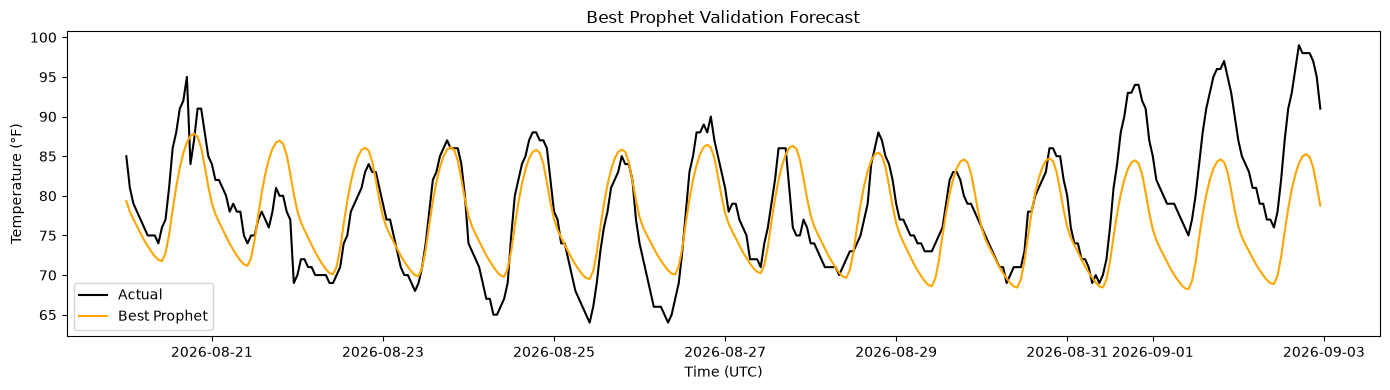

In [42]:
plt.figure(figsize=(14, 4))
plt.plot(best_validation["ds"], best_validation["y"], label="Actual", color="black")
plt.plot(best_validation["ds"], best_validation["yhat"], label="Best Prophet", color="orange")
plt.xlabel("Time (UTC)")
plt.ylabel("Temperature (°F)")
plt.title("Best Prophet Validation Forecast")
plt.legend()
plt.tight_layout()
plt.show()

## Tuning Notes

1. The best validation MAE came from a smoother trend: `changepoint_prior_scale=0.01`.
2. Weekly seasonality helped compared with the baseline daily/yearly model.
3. A higher yearly Fourier order helped capture the late-summer seasonal shape.
4. The deterministic cyclical regressors did not improve validation error, likely because they duplicate Prophet's built-in seasonality.
5. The final model should lock these parameters, refit on train + validation, and evaluate once on test outside this experiment notebook.